# Proyecto data Analytics

## Introduccion

Aquí iría la introducción.

## Paso 0: Importe de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, ttest_1samp, levene, pearsonr

## Paso 1: Abre el archivo de datos y estudia la información general

Vamos a cargar nuestro dataset

In [4]:
df = pd.read_csv("traffic_accidents.csv")

Ahora vamos a validar nuestro dataset

In [7]:
df.head(2)

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8


## Paso 2: Prepara los datos

### 2.1 Reemplaza los nombres de las columnas (ponlos en minúsculas).

In [8]:
df.columns

Index(['crash_date', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type',
       'intersection_related_i', 'damage', 'prim_contributory_cause',
       'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour',
       'crash_day_of_week', 'crash_month'],
      dtype='object')

### 2.2 Convierte los datos en los tipos necesarios.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  object 
 1   traffic_control_device         209306 non-null  object 
 2   weather_condition              209306 non-null  object 
 3   lighting_condition             209306 non-null  object 
 4   first_crash_type               209306 non-null  object 
 5   trafficway_type                209306 non-null  object 
 6   alignment                      209306 non-null  object 
 7   roadway_surface_cond           209306 non-null  object 
 8   road_defect                    209306 non-null  object 
 9   crash_type                     209306 non-null  object 
 10  intersection_related_i         209306 non-null  object 
 11  damage                         209306 non-null  object 
 12  prim_contributory_cause       

### 2.3 Describe las columnas en las que los tipos de datos han sido cambiados y explica por qué.

No voy a cambiar ninguna columna.

### 2.4 Valores ausentes

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  object 
 1   traffic_control_device         209306 non-null  object 
 2   weather_condition              209306 non-null  object 
 3   lighting_condition             209306 non-null  object 
 4   first_crash_type               209306 non-null  object 
 5   trafficway_type                209306 non-null  object 
 6   alignment                      209306 non-null  object 
 7   roadway_surface_cond           209306 non-null  object 
 8   road_defect                    209306 non-null  object 
 9   crash_type                     209306 non-null  object 
 10  intersection_related_i         209306 non-null  object 
 11  damage                         209306 non-null  object 
 12  prim_contributory_cause       

### 2.5 En qué mes hubo más accidentes

<Figure size 200x200 with 0 Axes>

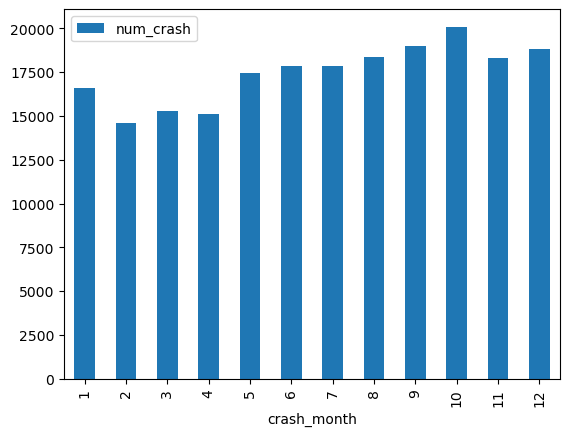

In [19]:
df_2_5 = df.groupby('crash_month')['crash_date'].count().rename("num_crash").reset_index()
plt.figure(figsize=(2,2))
df_2_5.plot(x='crash_month', y='num_crash', kind='bar')
plt.show()

## Paso 3: Analiza los datos

<Axes: ylabel='weather_condition'>

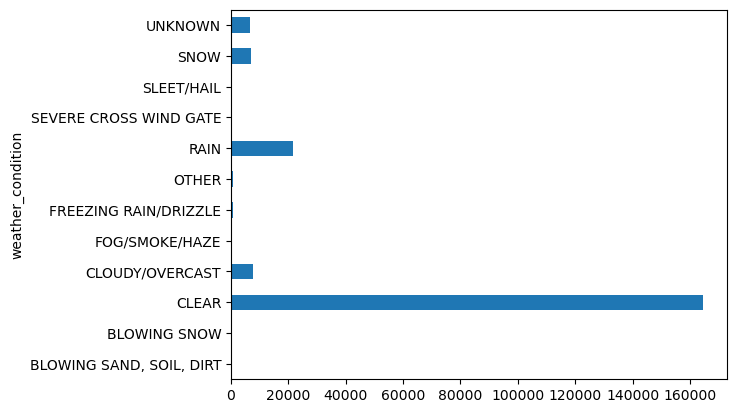

In [24]:
df_3_1 = df.groupby('weather_condition')['crash_date'].count().rename('num_acc')
df_3_1.plot(kind='barh')

In [30]:
df_agg = df.groupby('weather_condition').agg({'crash_hour': ['min', 'max']}).reset_index()
df_agg.head(2)

weather_condition crash_hour    
                                   min max
0  BLOWING SAND, SOIL, DIRT         10  10
1              BLOWING SNOW          1  23

In [31]:
df_agg.columns

MultiIndex([('weather_condition',    ''),
            (       'crash_hour', 'min'),
            (       'crash_hour', 'max')],
           )

In [37]:
df_agg['col1'] = df_agg[('crash_hour', 'max')] - df_agg[('crash_hour', 'min')]

In [38]:
df_agg.head(2)

weather_condition crash_hour     col1
                                   min max     
0  BLOWING SAND, SOIL, DIRT         10  10    0
1              BLOWING SNOW          1  23   22

## Paso 4: Crea un perfil de usuario para cada región

## Paso 5: Prueba las siguientes hipótesis

**Hipotesis:** ¿Difieren las lesiones en función de las condiciones climáticas?

- **H0:** No hay diferencia.
- **H1:** Si hay diferencia.

In [46]:
clear_weather = df[df['weather_condition'] == 'CLEAR']['injuries_total']
other_weather = df[df['weather_condition'] != 'CLEAR']['injuries_total']

In [48]:
stat, p = levene(clear_weather, other_weather)
p

2.9896254804353725e-17

In [51]:
alpha = 0.05

In [52]:
stat, pvalue = ttest_ind(clear_weather, other_weather, equal_var=False)
print(pvalue)

8.76302726103415e-19


## Paso 6. Escribe una conclusión general

Una conclusión :)

- Item 1
- Item 2
- Item 3